In [6]:
!pip install igraph
!pip install reinmax

In [7]:
import os
import time
import copy
import math
import random
import typing
import functools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import igraph as ig

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torch.distributions import MultivariateNormal

from sklearn.metrics import roc_auc_score
from reinmax import reinmax

# ==========================================
# Configuration & Seeds
# ==========================================

def set_random_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

CONFIG = {
    'seed': 0,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'gpu_index': "3",
    'num_nodes': 20,
    'edge_num': 30,
    'n_samples': 10000,
    'batch_size': 256,
    'n_epochs': 300,
    'lr': 1e-3,
    'eps': 1e-5,
    'embed_dim': 512,
    'n_layer': 1,
    'sigma': 25.0
}

# Set device
if torch.cuda.is_available():
    os.environ['CUDA_VISIBLE_DEVICES'] = CONFIG['gpu_index']
    torch.set_default_dtype(torch.float32)

set_random_seed(CONFIG['seed'])
device = CONFIG['device']
print(f"Running on {device}")


Running on cuda


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!ls /content/drive/MyDrive/

 AA1100DD-491D-4AAC-8F15-493218508522.mov
 checkpoint_d50.pth
 checkpoint_d80.pth
'Chenyu Gu _ Final-spr.docx'
'Chenyu Gu-Resuem_CV - Final (1).pdf'
'Chenyu Gu-Resuem_CV - Final (2).pdf'
'Chenyu Gu-Resuem_CV - Final.pdf'
'Chenyu Gu-Resuem_Research.pdf'
'Chenyu Gu Resume - 10.10.pdf'
 chenyu.gu_uchicago_2027_resume.pdf
 Chenyu+Paper+4-1.docx
'Colab Notebooks'
 copy_01E28FCF-95C4-4792-B617-151B39B03C55.mov
 copy_1BC669F1-6D8D-4698-B1B6-ECD85ED91BF3.mov
 copy_BD6D0021-915A-42A3-A9AF-41B036C54381.mov
 copy_FA9AD4F9-2E41-4561-9D03-E1CEBC60C977.mov
 copy_FC9BF93D-8D3B-4529-8879-9EE6C5BBDAC8.mov
'Denver Travel Budget.gsheet'
'Denver Travel Budget.xlsx'
 Diffusion_new.pptx
 Diffusion_node.pptx
 Diffusion_origin.pptx
 Diffusion_squared.pptx
'FitChicago Weekly Class Schedule.xlsx'
 《Holes》词汇表更新与解析.gsheet
'Human Experience.pptx'
'IMG_202407237256_616x792 (1).jpg'
 IMG_202407237256_616x792.jpg
 Mmm.gdoc
 Path
 Path_node_num
 Path_squared
 Path_squared_new
'Report - Chenyu.docx'
 Review.gdoc
'Scree

In [10]:
# ==========================================
# DAG Utils
# ==========================================

def is_dag(W: np.ndarray) -> bool:
    """Returns ``True`` if ``W`` is a DAG, ``False`` otherwise."""
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    return G.is_dag()

def simulate_dag(d: int, s0: int, graph_type: str) -> np.ndarray:
    """Simulate random DAG with some expected number of edges."""
    def _random_permutation(M):
        P = np.random.permutation(np.eye(M.shape[0]))
        return P.T @ M @ P

    def _random_acyclic_orientation(B_und):
        return np.tril(_random_permutation(B_und), k=-1)

    def _graph_to_adjmat(G):
        return np.array(G.get_adjacency().data)

    if graph_type == 'ER':
        G_und = ig.Graph.Erdos_Renyi(n=d, m=s0)
        B_und = _graph_to_adjmat(G_und)
        B = _random_acyclic_orientation(B_und)
    elif graph_type == 'SF':
        G = ig.Graph.Barabasi(n=d, m=int(round(s0 / d)), directed=True)
        B = _graph_to_adjmat(G)
    elif graph_type == 'BP':
        top = int(0.2 * d)
        G = ig.Graph.Random_Bipartite(top, d - top, m=s0, directed=True, neimode=ig.OUT)
        B = _graph_to_adjmat(G)
    elif graph_type == 'Fully':
        B = np.triu(np.ones((d, d)), 1)
    else:
        raise ValueError('unknown graph type')

    B_perm = _random_permutation(B)
    assert ig.Graph.Adjacency(B_perm.tolist()).is_dag()
    return B_perm

def simulate_linear_sem(W: np.ndarray, n: int, sem_type: str, noise_scale: typing.Optional[typing.Union[float, typing.List[float]]] = None) -> np.ndarray:
    """Simulate samples from linear SEM."""
    from scipy.special import expit as sigmoid

    def _simulate_single_equation(X, w, scale):
        if sem_type == 'gauss':
            z = np.random.normal(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'exp':
            z = np.random.exponential(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'gumbel':
            z = np.random.gumbel(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'uniform':
            z = np.random.uniform(low=-scale, high=scale, size=n)
            x = X @ w + z
        elif sem_type == 'logistic':
            x = np.random.binomial(1, sigmoid(X @ w)) * 1.0
        elif sem_type == 'poisson':
            x = np.random.poisson(np.exp(X @ w)) * 1.0
        else:
            raise ValueError('unknown sem type')
        return x

    d = W.shape[0]
    if noise_scale is None:
        scale_vec = np.ones(d)
    elif np.isscalar(noise_scale):
        scale_vec = noise_scale * np.ones(d)
    else:
        scale_vec = noise_scale

    if not is_dag(W):
        raise ValueError('W must be a DAG')

    if np.isinf(n):
        if sem_type == 'gauss':
            X = np.sqrt(d) * np.diag(scale_vec) @ np.linalg.inv(np.eye(d) - W)
            return X
        else:
            raise ValueError('population risk not available')

    G = ig.Graph.Weighted_Adjacency(W.tolist())
    ordered_vertices = G.topological_sorting()
    X = np.zeros([n, d])
    for j in ordered_vertices:
        parents = G.neighbors(j, mode=ig.IN)
        X[:, j] = _simulate_single_equation(X[:, parents], W[parents, j], scale_vec[j])
    return X

def simulate_nonlinear_sem(B: np.ndarray, n: int, sem_type: str, noise_scale: typing.Optional[typing.Union[float, typing.List[float]]] = None) -> np.ndarray:
    """Simulate samples from nonlinear SEM."""
    from scipy.special import expit as sigmoid

    def _simulate_single_equation(X, scale):
        z = np.random.normal(scale=scale, size=n)
        pa_size = X.shape[1]
        if pa_size == 0:
            return z
        if sem_type == 'mlp':
            hidden = 100
            W1 = np.random.uniform(low=0.5, high=2.0, size=[pa_size, hidden])
            W1[np.random.rand(*W1.shape) < 0.5] *= -1
            W2 = np.random.uniform(low=0.5, high=2.0, size=hidden)
            W2[np.random.rand(hidden) < 0.5] *= -1
            x = sigmoid(X @ W1) @ W2 + z
        elif sem_type == 'mim':
            w1 = np.random.uniform(low=0.5, high=2.0, size=pa_size)
            w1[np.random.rand(pa_size) < 0.5] *= -1
            w2 = np.random.uniform(low=0.5, high=2.0, size=pa_size)
            w2[np.random.rand(pa_size) < 0.5] *= -1
            w3 = np.random.uniform(low=0.5, high=2.0, size=pa_size)
            w3[np.random.rand(pa_size) < 0.5] *= -1
            x = np.tanh(X @ w1) + np.cos(X @ w2) + np.sin(X @ w3) + z
        else:
             raise ValueError('unknown sem type')
        return x

    d = B.shape[0]
    scale_vec = noise_scale if noise_scale else np.ones(d)
    X = np.zeros([n, d])
    G = ig.Graph.Adjacency(B.tolist())
    ordered_vertices = G.topological_sorting()
    for j in ordered_vertices:
        parents = G.neighbors(j, mode=ig.IN)
        X[:, j] = _simulate_single_equation(X[:, parents], scale_vec[j])
    return X


In [11]:
for sample in range(5):
    for node_number in [20,30,50]:
        _graph_adj = simulate_dag(node_number, 4*node_number, 'ER')
        data = simulate_linear_sem(_graph_adj, 10000, 'gauss')
        torch.save({
            'data': data,
            'graph_adj': _graph_adj
        }, f'/content/drive/MyDrive/Path_squared_new/data_{sample}_{node_number}.pt')

In [12]:
# ==========================================
# Dataset Classes
# ==========================================

class DAGDataset(Dataset):
    def __init__(self, node_num, edge_num, n_samples, linear, DAG_type, SEM_type, device, data, graph_adj):
        self._node_num = node_num
        self._edge_num = edge_num
        self.n_samples = n_samples
        self.DAG_type = DAG_type
        self.SEM_type = SEM_type
        self.device = device
        self._graph_adj = graph_adj
        self.data = data

    @property
    def node_num(self):
        return self._node_num

    @property
    def edge_num(self):
        return self._edge_num

    @property
    def graph_adj(self):
        return self._graph_adj

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.data[idx, :]


In [13]:
# ==========================================
# Model Components
# ==========================================

def new_gelu(x):
    return 0.5 * x * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3.0))))

class MLP(nn.Module):
    def __init__(self, n_embd, bias=False, dropout=0.0):
        super().__init__()
        self.c_fc = nn.Linear(n_embd, 4 * n_embd, bias=bias)
        self.c_proj = nn.Linear(4 * n_embd, n_embd, bias=bias)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = new_gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class Dense(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.dense(x)

class SelfAttention(nn.Module):
    def __init__(self, n_embd=768, n_head=12, bias=True, dropout=0.0):
        super().__init__()
        assert n_embd % n_head == 0
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=bias)
        self.c_proj = nn.Linear(n_embd, n_embd, bias=bias)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.n_head = n_head
        self.n_embd = n_embd
        self.dropout = dropout
        self.flash = False

    def forward(self, x, att_mask=None):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = F.softmax(att, dim=-1)
        if att_mask is not None:
            att = att * att_mask
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class EncoderLayer(nn.Module):
    def __init__(self, n_embd=768, n_head=12, bias=True, dropout=0.0):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        self.attn = SelfAttention(n_embd=n_embd, n_head=n_head, bias=bias, dropout=dropout)
        self.ln_2 = nn.LayerNorm(n_embd)
        self.mlp = MLP(n_embd=n_embd, dropout=dropout)

    def forward(self, x, att_mask=None):
        out = self.attn(self.ln_1(x), att_mask=att_mask)
        x = x + out
        x = x + self.mlp(self.ln_2(x))
        return x

class TimeAwareResBlock(nn.Module):
    def __init__(self, embed_dim, t_emb_out_dim=None):
        super().__init__()
        self.layer = Dense(embed_dim, embed_dim)
        self.act = nn.SiLU(inplace=True)
        self.ln = nn.LayerNorm(embed_dim)
        self.t_emb = Dense(embed_dim, t_emb_out_dim if t_emb_out_dim else embed_dim)

    def forward(self, x, t_embed):
        x_res = x
        t_proj = self.t_emb(t_embed)[:, None, :]
        x = self.layer(x + t_proj)
        x = self.act(x) + x_res
        return self.ln(x)

class GraphLDiffusion(nn.Module):
    def __init__(self, input_size, embed_dim=256, n_layer=8):
        super().__init__()
        self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
                                   nn.Linear(embed_dim, embed_dim))
        self.denses = nn.ModuleList([Dense(embed_dim, embed_dim) for _ in range(n_layer)])
        self.target_embed = nn.Embedding(input_size, embed_dim)

        self.EncoderLayers = nn.ModuleList(
            [EncoderLayer(n_embd=embed_dim, n_head=32, bias=False, dropout=0.0) for _ in range(n_layer)])

        self.ln = nn.LayerNorm(embed_dim, bias=True)

        # Initial blocks (a, b, c, d)
        self.initial_blocks = nn.ModuleList([TimeAwareResBlock(embed_dim) for _ in range(4)])

        # Final blocks (a, b, c)
        self.final_blocks = nn.ModuleList([
            TimeAwareResBlock(embed_dim),
            TimeAwareResBlock(embed_dim),
            TimeAwareResBlock(embed_dim, t_emb_out_dim=1)
        ])

        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layer))


        self.act = lambda x: x * torch.sigmoid(x)
        self.att_mask_pro = nn.Parameter(torch.ones(input_size, input_size, 2))
        self.x_layer_weight = nn.Parameter(torch.ones(n_layer))

    def forward(self, x, t, targets=None):
        embed = self.act(self.embed(t))
        x = (x[:, :, None] * self.target_embed.weight[None, :, :])

        # Initial Processing
        for block in self.initial_blocks:
            x = block(x, embed)

        # Attention Mask
        attn_mask_hard, _ = reinmax(self.att_mask_pro, tau=2)
        attn_mask_hard = attn_mask_hard[:, :, 1]

        # Encoder Layers
        x_list = []
        for enc_layer, dense in zip(self.EncoderLayers, self.denses):
            x = enc_layer(x + dense(embed)[:, None, :], att_mask=attn_mask_hard)
            x_list.append(x)

        x = torch.stack(x_list, dim=0)
        x = torch.sum(x * self.x_layer_weight[:, None, None, None], dim=0)
        x = self.ln(x)

        # Final Processing
        for block in self.final_blocks:
            x = block(x, embed)

        out = x[:, :, 0]
        return out, attn_mask_hard


In [14]:
# ==========================================
# Diffusion Utils
# ==========================================

def marginal_prob_std(t, sigma):
    return torch.sqrt((sigma ** (2 * t) - 1.) / 2. / np.log(sigma))

def diffusion_coeff(t, sigma):
    return torch.tensor(sigma ** t, device=device)

marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=CONFIG['sigma'])


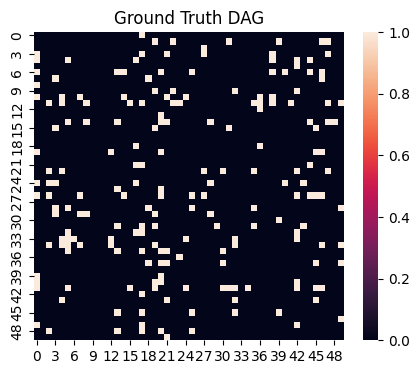

In [15]:
# ==========================================
# Training
# ==========================================

# Prepare Data
sample = 0 # 0-4
node_num = 20
edge_num = 4*node_num
n_samples = 10000
linear = True
DAG_type = 'ER'
SEM_type = 'gauss'
device = 'cuda'
data_all = torch.load(f'/content/drive/MyDrive/Path_squared_new/data_{sample}_{node_number}.pt', weights_only=False)
data = data_all['data']
graph_adj = data_all['graph_adj']
dataset = DAGDataset(
    node_num=node_num,
    edge_num=edge_num,
    n_samples=n_samples,
    linear=linear,
    DAG_type=DAG_type,
    SEM_type=SEM_type,
    device=device,
    data=data,
    graph_adj=graph_adj
)
data_loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)

# Plot Ground Truth
plt.figure(figsize=(5, 4))
sns.heatmap(dataset.graph_adj)
plt.title("Ground Truth DAG")
plt.show()

Starting training for 3 node configurations and 5 samples each...

====== Training for Node Number: 20 ======

=== Starting Run for Sample 0 ===
Node 20 | Sample 0 | Epoch 0 | AUC: 0.523271 | Score Loss: 1.140283
Node 20 | Sample 0 | Epoch 100 | AUC: 0.688250 | Score Loss: 0.694163


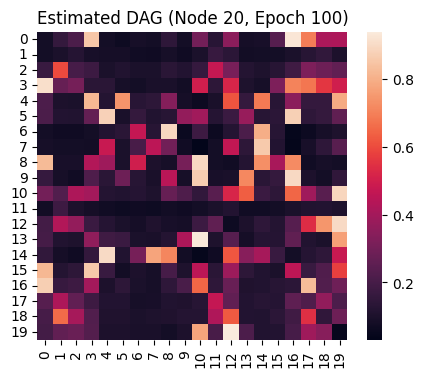

Node 20 | Sample 0 | Epoch 200 | AUC: 0.725250 | Score Loss: 0.650072
Node 20 | Sample 0 | Epoch 299 | AUC: 0.762042 | Score Loss: 0.627039
Finished Node 20, Sample 0. Final AUC: 0.762042

=== Starting Run for Sample 1 ===
Node 20 | Sample 1 | Epoch 0 | AUC: 0.536000 | Score Loss: 1.301218
Node 20 | Sample 1 | Epoch 100 | AUC: 0.693333 | Score Loss: 0.685777


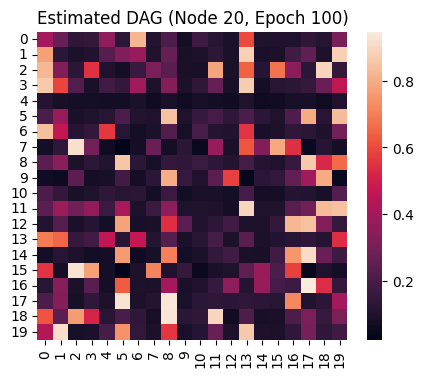

Node 20 | Sample 1 | Epoch 200 | AUC: 0.708000 | Score Loss: 0.641409
Node 20 | Sample 1 | Epoch 299 | AUC: 0.728750 | Score Loss: 0.610533
Finished Node 20, Sample 1. Final AUC: 0.728750

=== Starting Run for Sample 2 ===
Node 20 | Sample 2 | Epoch 0 | AUC: 0.531500 | Score Loss: 1.158418
Node 20 | Sample 2 | Epoch 100 | AUC: 0.674667 | Score Loss: 0.704818


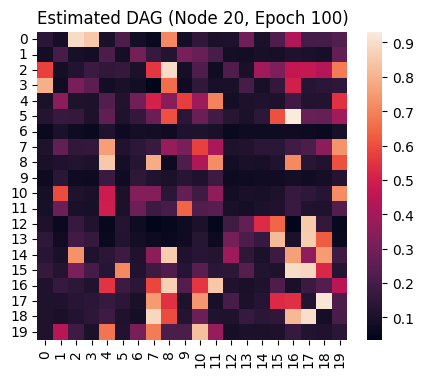

Node 20 | Sample 2 | Epoch 200 | AUC: 0.709083 | Score Loss: 0.666533
Node 20 | Sample 2 | Epoch 299 | AUC: 0.762458 | Score Loss: 0.627268
Finished Node 20, Sample 2. Final AUC: 0.762458

=== Starting Run for Sample 3 ===
Node 20 | Sample 3 | Epoch 0 | AUC: 0.586583 | Score Loss: 1.213495
Node 20 | Sample 3 | Epoch 100 | AUC: 0.716375 | Score Loss: 0.691602


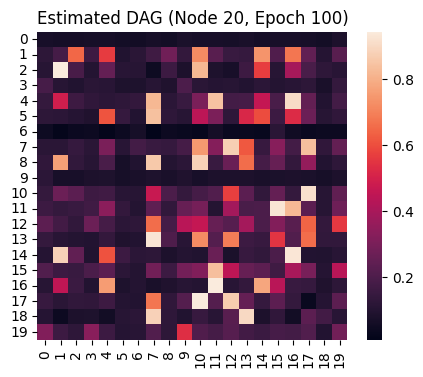

Node 20 | Sample 3 | Epoch 200 | AUC: 0.746750 | Score Loss: 0.662684
Node 20 | Sample 3 | Epoch 299 | AUC: 0.760875 | Score Loss: 0.635112
Finished Node 20, Sample 3. Final AUC: 0.760875

=== Starting Run for Sample 4 ===
Node 20 | Sample 4 | Epoch 0 | AUC: 0.544750 | Score Loss: 1.333503
Node 20 | Sample 4 | Epoch 100 | AUC: 0.728792 | Score Loss: 0.705545


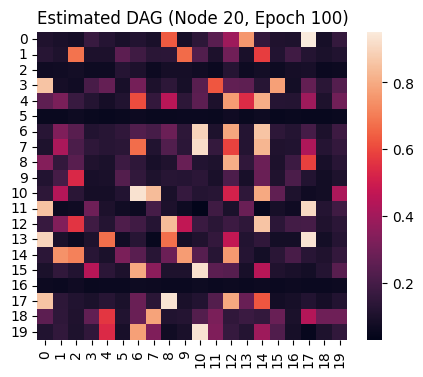

Node 20 | Sample 4 | Epoch 200 | AUC: 0.760250 | Score Loss: 0.667501
Node 20 | Sample 4 | Epoch 299 | AUC: 0.779625 | Score Loss: 0.646590
Finished Node 20, Sample 4. Final AUC: 0.779625

====== Training for Node Number: 30 ======

=== Starting Run for Sample 0 ===
Node 30 | Sample 0 | Epoch 0 | AUC: 0.546156 | Score Loss: 1.133498
Node 30 | Sample 0 | Epoch 100 | AUC: 0.665067 | Score Loss: 0.743889


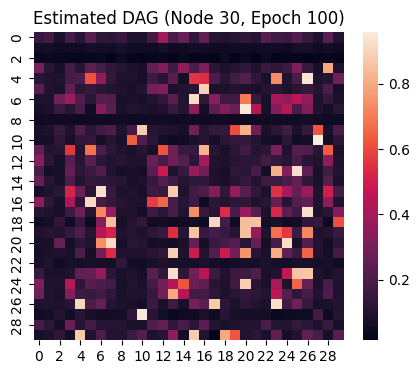

Node 30 | Sample 0 | Epoch 200 | AUC: 0.718589 | Score Loss: 0.691835
Node 30 | Sample 0 | Epoch 299 | AUC: 0.760978 | Score Loss: 0.653601
Finished Node 30, Sample 0. Final AUC: 0.760978

=== Starting Run for Sample 1 ===
Node 30 | Sample 1 | Epoch 0 | AUC: 0.498539 | Score Loss: 1.073438
Node 30 | Sample 1 | Epoch 100 | AUC: 0.715722 | Score Loss: 0.734970


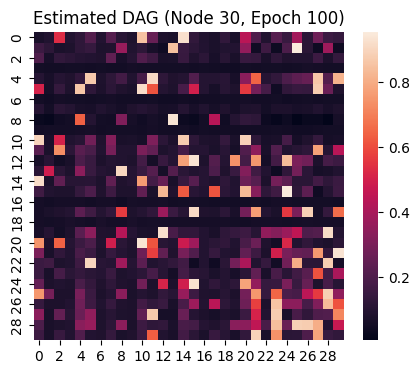

Node 30 | Sample 1 | Epoch 200 | AUC: 0.762156 | Score Loss: 0.698147
Node 30 | Sample 1 | Epoch 299 | AUC: 0.776811 | Score Loss: 0.669678
Finished Node 30, Sample 1. Final AUC: 0.776811

=== Starting Run for Sample 2 ===
Node 30 | Sample 2 | Epoch 0 | AUC: 0.600239 | Score Loss: 1.107616
Node 30 | Sample 2 | Epoch 100 | AUC: 0.801667 | Score Loss: 0.703035


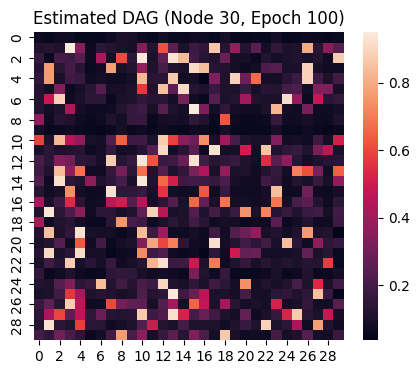

Node 30 | Sample 2 | Epoch 200 | AUC: 0.824433 | Score Loss: 0.655161
Node 30 | Sample 2 | Epoch 299 | AUC: 0.841022 | Score Loss: 0.640401
Finished Node 30, Sample 2. Final AUC: 0.841022

=== Starting Run for Sample 3 ===
Node 30 | Sample 3 | Epoch 0 | AUC: 0.582889 | Score Loss: 1.058692
Node 30 | Sample 3 | Epoch 100 | AUC: 0.724400 | Score Loss: 0.724147


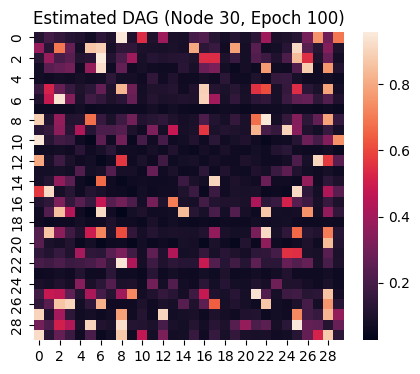

Node 30 | Sample 3 | Epoch 200 | AUC: 0.740522 | Score Loss: 0.696268
Node 30 | Sample 3 | Epoch 299 | AUC: 0.761022 | Score Loss: 0.667767
Finished Node 30, Sample 3. Final AUC: 0.761022

=== Starting Run for Sample 4 ===
Node 30 | Sample 4 | Epoch 0 | AUC: 0.614278 | Score Loss: 1.221934
Node 30 | Sample 4 | Epoch 100 | AUC: 0.703756 | Score Loss: 0.732225


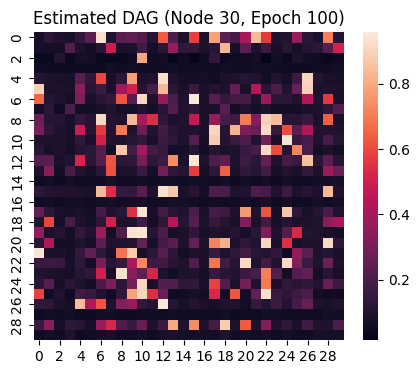

Node 30 | Sample 4 | Epoch 200 | AUC: 0.721911 | Score Loss: 0.696758
Node 30 | Sample 4 | Epoch 299 | AUC: 0.747444 | Score Loss: 0.679128
Finished Node 30, Sample 4. Final AUC: 0.747444

====== Training for Node Number: 50 ======

=== Starting Run for Sample 0 ===
Node 50 | Sample 0 | Epoch 0 | AUC: 0.525818 | Score Loss: 1.091939
Node 50 | Sample 0 | Epoch 100 | AUC: 0.714333 | Score Loss: 0.717471


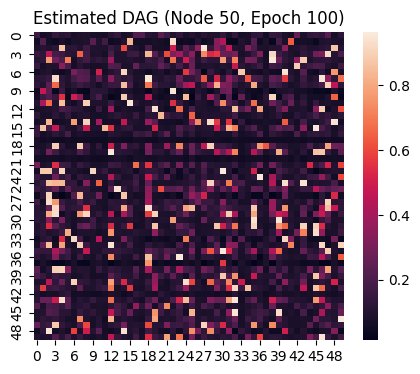

Node 50 | Sample 0 | Epoch 200 | AUC: 0.779509 | Score Loss: 0.674847
Node 50 | Sample 0 | Epoch 299 | AUC: 0.813556 | Score Loss: 0.657086
Finished Node 50, Sample 0. Final AUC: 0.813556

=== Starting Run for Sample 1 ===
Node 50 | Sample 1 | Epoch 0 | AUC: 0.594139 | Score Loss: 1.089462


In [ ]:
import numpy as np

# ==========================================
# Training Loop over Samples
# ==========================================

samples_list = range(5) # As generated in the previous cells
node_numbers_to_train = [20,30,50] # Node numbers for which data was generated
results = {}

print(f"Starting training for {len(node_numbers_to_train)} node configurations and {len(samples_list)} samples each...")

for current_node_num in node_numbers_to_train:
    current_edge_num = 4 * current_node_num # Adjust edge_num based on node_num
    print(f"\n====== Training for Node Number: {current_node_num} ======")

    for sample in samples_list:
        print(f"\n=== Starting Run for Sample {sample} ===")

        data_path = f'/content/drive/MyDrive/Path_squared_new/data_{sample}_{current_node_num}.pt'
        data_all = torch.load(data_path, weights_only=False)
        data = data_all['data']
        graph_adj = data_all['graph_adj']

        dataset = DAGDataset(
            node_num=current_node_num,
            edge_num=current_edge_num,
            n_samples=CONFIG['n_samples'],
            linear=True,
            DAG_type='ER',
            SEM_type='gauss',
            device=CONFIG['device'],
            data=data,
            graph_adj=graph_adj
        )
        data_loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)

        # Initialize model with current_node_num
        score_model = GraphLDiffusion(current_node_num, embed_dim=CONFIG['embed_dim'], n_layer=CONFIG['n_layer'])
        score_model = score_model.to(device)
        optimizer = Adam(score_model.parameters(), lr=CONFIG['lr'])
        score_loss_arr = []

        for epoch in range(CONFIG['n_epochs']):
            score_model.train()
            for x in data_loader:
                x = x.to(device)
                random_t = torch.rand(x.shape[0], device=x.device) * (1. - CONFIG['eps']) + CONFIG['eps']
                random_t = random_t * 0.5
                z = torch.randn_like(x)
                std = marginal_prob_std_fn(random_t)
                perturbed_x = x + z * std[:, None]

                score, attn_mask = score_model(perturbed_x.float(), random_t)

                loss_score = torch.mean(torch.sum((score * std[:, None] + z) ** 2, dim=(1)) / score.shape[1])
                loss_sparsity = torch.sum(torch.abs(attn_mask)) * 0.25/((current_node_num)**2)
                loss_all = loss_score + loss_sparsity

                score_loss_arr.append(loss_score.item())

                optimizer.zero_grad()
                loss_all.backward()
                optimizer.step()

            # Logging & Evaluation
            if epoch % 100 == 0 or epoch == CONFIG['n_epochs'] - 1:
                # Access att_mask_pro directly
                mask_hard, mask_soft = reinmax(score_model.att_mask_pro, tau=1)
                mask = mask_soft[:, :, 1].detach().cpu()

                # Calculate AUC
                index_no_d_auc = torch.eye(mask.size(0)) == 0
                off_diagonal_pred = mask[index_no_d_auc]
                off_diagonal_true = dataset.graph_adj[index_no_d_auc.numpy().astype(bool)].flatten()

                auc = roc_auc_score(off_diagonal_true, off_diagonal_pred.flatten())
                mean_score_loss = np.mean(score_loss_arr[-len(data_loader):])

                print(f'Node {current_node_num} | Sample {sample} | Epoch {epoch} | AUC: {auc:.6f} | Score Loss: {mean_score_loss:.6f}')

                # Save checkpoint periodically and at the end
                if epoch == 100:
                    plt.figure(figsize=(5, 4))
                    sns.heatmap(mask)
                    plt.title(f"Estimated DAG (Node {current_node_num}, Epoch {epoch})")
                    plt.show()
                if epoch >= CONFIG['n_epochs'] - 1:
                    # Update model_save_path to include node_num
                    model_save_path = f'/content/drive/MyDrive/Path_squared_new/checkpoint_d{current_node_num}_exp{sample}.pth'
                    torch.save(score_model.state_dict(), model_save_path)
                    break

        # Store final result in a nested dictionary
        if current_node_num not in results:
            results[current_node_num] = {}
        results[current_node_num][sample] = auc
        print(f"Finished Node {current_node_num}, Sample {sample}. Final AUC: {auc:.6f}")

print("\nAll runs completed.")
print("Final AUC Results per node number and sample:", results)